# 서울시 따릉이 데이터 전처리 및 ISLP 모델링 분석

이 노트북은 서울시 공공자전거(따릉이) 데이터와 기상/미세먼지 데이터를 결합하고, ISLP 다중선형회귀, 교호작용 분석, 비선형 회귀(Spline/Poly)까지 모두 수행하는 통합 파이프라인입니다.

**[Part I: 전처리 - 원본 대여 이력 데이터 보존 최적화]**
- 일 단위로 무작정 합산하지 않고, 개별 사용자의 **출발 시간대, 도착지, 이용 시간 및 거리** 등의 원본 이력을 모두 보존합니다.
- 타겟 대여소(Office, Leisure, University)에서 출발한 이력만을 필터링해 내어 CSV 파일들의 크기를 최적화합니다.
- 각 대여 이력에 해당 일자의 기온/강수량/미세먼지 데이터를 복사하여 붙여넣어(Left Join) 완벽한 통합 분석 테이블을 구성합니다.

## 1. 전처리 라이브러리 및 경로 설정

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import traceback

BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, 'data')

WEATHER_DIR = os.path.join(DATA_DIR, '기상정보(03.31_05.21)')
BIKE_DIR = os.path.join(DATA_DIR, '따릉이(03,04,05.01_05.15)')
MASTER_DIR = os.path.join(DATA_DIR, '따릉이_마스터정보(대여소_id)')
DUST_DIR = os.path.join(DATA_DIR, '미세먼지 정보(03.31_05.21)')

START_DATE = '2026-03-01'
END_DATE = '2026-05-15'

def find_encoding(file_path):
    for enc in ['utf-8', 'cp949', 'euc-kr']:
        try:
            pd.read_csv(file_path, encoding=enc, nrows=1)
            return enc
        except UnicodeDecodeError:
            continue
    return 'cp949'

## 2. 마스터 데이터 기반 타겟 대여소 추출
Office(오피스), Leisure(여가), University(대학 상권) 대여소를 필터링합니다.

In [2]:
try:
    def load_master_data():
        master_files = glob.glob(os.path.join(MASTER_DIR, '*.csv'))
        if not master_files:
            raise FileNotFoundError("마스터 데이터 폴더에 CSV 파일이 없습니다.")
        
        master_file = master_files[0]
        enc = find_encoding(master_file)
        master_df = pd.read_csv(master_file, encoding=enc)
        
        station_name_col = next((col for col in master_df.columns if '명' in col or '이름' in col), master_df.columns[2])
        station_id_col = next((col for col in master_df.columns if 'ID' in col.upper() or '번호' in col), master_df.columns[0])
        
        office_keywords = ['여의도역', '강남역', '광화문역', '을지로입구역', '시청역', '선릉역', '삼성역', '종각역', '가산디지털단지역', '판교역', '공덕역']
        leisure_keywords = ['여의나루역', '뚝섬유원지역', '서울숲역', '반포한강공원', '망원한강공원', '올림픽공원', '월드컵경기장', '어린이대공원', '노들섬', '석촌호수']
        university_keywords = ['공릉', '서울과학기술대학교']

        def assign_station_type(name):
            name = str(name)
            for kw in office_keywords:
                if kw in name: return 'Office'
            for kw in leisure_keywords:
                if kw in name: return 'Leisure'
            for kw in university_keywords:
                if kw in name: return 'University'
            return None

        master_df['station_type'] = master_df[station_name_col].apply(assign_station_type)
        target_master_df = master_df.dropna(subset=['station_type']).copy()
        
        target_master_df = target_master_df[[station_id_col, station_name_col, 'station_type']]
        target_master_df.columns = ['station_id', 'station_name', 'station_type']
        target_master_df = target_master_df.drop_duplicates(subset=['station_id'])
        
        return target_master_df

    target_master_df = load_master_data()
    print(f"{len(target_master_df)}개의 타겟 대여소 식별 완료.")
    display(target_master_df.head())
except Exception as e:
    print("마스터 데이터 로드 중 오류 발생:")
    traceback.print_exc()

31개의 타겟 대여소 식별 완료.


,station_id,station_name,station_type
10,ST-99,뚝섬유원지역 1번출구 앞,Leisure
48,ST-955,삼성역 5~6번 출구,Office
143,ST-87,홈플러스 월드컵경기장점,Leisure
214,ST-805,삼성역 3번 출구,Office
219,ST-800,삼성역 7번출구,Office


## 3. 대규모 따릉이 원본 이력 추출

In [3]:
try:
    def load_and_filter_raw_bike_data(folder_path, target_master_df):
        all_files = glob.glob(os.path.join(folder_path, '**', '*.csv'), recursive=True)
        df_list = []
        
        target_station_ids = target_master_df['station_id'].unique()

        for file in all_files:
            enc = find_encoding(file)
            df = pd.read_csv(file, encoding=enc)
            
            start_id_cols = [c for c in df.columns if '시작' in c and 'ID' in c.upper()]
            if not start_id_cols:
                start_id_cols = [c for c in df.columns if '대여소_ID' in c.upper() or '대여대여소' in c]
                
            if not start_id_cols: continue
                
            join_col = start_id_cols[0]
            
            filtered_df = df[df[join_col].isin(target_station_ids)].copy()
            if filtered_df.empty: continue
                
            filtered_df = pd.merge(filtered_df, target_master_df[['station_id', 'station_type']], left_on=join_col, right_on='station_id', how='inner')
            filtered_df.drop(columns=['station_id'], inplace=True)
            
            date_col = next((c for c in filtered_df.columns if '날짜' in c or '일자' in c), filtered_df.columns[0])
            filtered_df['date'] = pd.to_datetime(filtered_df[date_col].astype(str).str.replace('-', ''), errors='coerce').dt.normalize()
            filtered_df = filtered_df.dropna(subset=['date'])
            
            df_list.append(filtered_df)
                
        if not df_list:
            return pd.DataFrame()
            
        merged_bike_df = pd.concat(df_list, ignore_index=True)
        return merged_bike_df

    bike_raw_df = load_and_filter_raw_bike_data(BIKE_DIR, target_master_df)
    if bike_raw_df.empty:
        print("따릉이 데이터가 비어있습니다. 경로를 확인해주세요.")
    else:
        print(f"필터링된 원본 데이터 병합 완료: 총 {len(bike_raw_df):,} 건")
        display(bike_raw_df.head())
except Exception as e:
    print("따릉이 이력 로드 중 오류 발생:")
    traceback.print_exc()

필터링된 원본 데이터 병합 완료: 총 232,648 건


,기준_날짜,집계_기준,기준_시간대,시작_대여소_ID,시작_대여소명,종료_대여소_ID,종료_대여소명,전체_건수,전체_이용_분,전체_이용_거리,station_type,date
0,20260508,출발시간,1540,ST-1586,잠실6동_001_1,ST-811,역삼1동_009_1,4,195.0,30067.0,Leisure,2026-05-08
1,20260508,출발시간,1400,ST-73,여의동_010_1,ST-3401,여의동_006_9,1,91.0,7210.0,Leisure,2026-05-08
2,20260508,출발시간,1740,ST-99,자양3동_036_1,ST-1335,면목2동_026_1,1,62.0,12552.0,Leisure,2026-05-08
3,20260508,출발시간,1925,ST-1720,오륜동_001_4,ST-505,성내3동_012_1,1,13.0,2080.0,Leisure,2026-05-08
4,20260508,출발시간,1655,ST-73,여의동_010_1,ST-2491,가양1동_001_3,1,52.0,11009.0,Leisure,2026-05-08


## 4. 기상 및 미세먼지 환경 데이터 보간 (지점번호 108번 강력 필터링)

In [4]:
try:
    def load_environment_data(folder_path, value_col_hints, output_col_name):
        all_files = glob.glob(os.path.join(folder_path, '**', '*.csv'), recursive=True)
        df_list = []
        
        for file in all_files:
            enc = find_encoding(file)
            df = pd.read_csv(file, encoding=enc)
            
            # 지점코드 확인 및 108 필터링
            station_col = next((c for c in df.columns if '지점' in c), None)
            if not station_col:
                station_col = df.columns[0] # 통상 첫 컬럼이 지점코드
                
            station_ids = pd.to_numeric(df[station_col], errors='coerce')
            df = df[station_ids == 108].copy() # 108번 서울 이외 타 지점 완벽 배제
            if df.empty:
                continue
            
            date_col = next((c for c in df.columns if '일시' in c or '일자' in c or '날짜' in c), None)
            if not date_col:
                date_col = df.columns[2] # 3번째 컬럼
                
            val_cols = []
            for hint in value_col_hints:
                found = next((c for c in df.columns if hint in c), None)
                if found: val_cols.append(found)
                
            if val_cols:
                sub_df = df[[date_col] + val_cols].copy()
                sub_df['date'] = pd.to_datetime(sub_df[date_col], errors='coerce').dt.normalize()
                sub_df = sub_df.dropna(subset=['date'])
                sub_df = sub_df.drop(columns=[date_col])
                df_list.append(sub_df)
                
        if not df_list:
            return pd.DataFrame()
            
        merged_env = pd.concat(df_list, ignore_index=True)
        merged_env = merged_env.groupby('date').mean().reset_index()
        
        rename_dict = {}
        for hint, out_name in zip(value_col_hints, output_col_name):
            found = next((c for c in merged_env.columns if hint in c), None)
            if found:
                rename_dict[found] = out_name
                
        merged_env = merged_env.rename(columns=rename_dict)
        return merged_env

    weather_df = load_environment_data(WEATHER_DIR, ['기온', '강수'], ['temp', 'precip'])
    dust_df = load_environment_data(DUST_DIR, ['미세먼지', 'PM10'], ['pm10', 'pm10'])

    if not weather_df.empty and not dust_df.empty:
        env_df = pd.merge(weather_df, dust_df, on='date', how='outer')
    else:
        env_df = weather_df if not weather_df.empty else dust_df

    if env_df.empty:
        print("환경 데이터를 로드하지 못했습니다. 파일에 108 지점 데이터가 있는지 확인하세요.")
    else:
        env_df.set_index('date', inplace=True)
        env_df.sort_index(inplace=True)

        target_dates = pd.date_range(start=START_DATE, end=END_DATE)
        env_df = env_df.reindex(target_dates)

        if 'precip' in env_df.columns:
            env_df['precip'] = env_df['precip'].fillna(0)
        if 'temp' in env_df.columns:
            env_df['temp'] = env_df['temp'].interpolate(method='time').bfill().ffill()
        if 'pm10' in env_df.columns:
            env_df['pm10'] = env_df['pm10'].interpolate(method='time').bfill().ffill()
            
        env_df.reset_index(inplace=True)
        env_df.rename(columns={'index': 'date'}, inplace=True)
        print("환경 데이터 보간 처리 완료 (지점: 108 서울 전용).")
        display(env_df.head())
except Exception as e:
    print("환경 데이터 로드 중 오류 발생:")
    traceback.print_exc()

환경 데이터 보간 처리 완료 (지점: 108 서울 전용).


,date,temp,precip,pm10
0,2026-03-01,9.1,0.53,22.0
1,2026-03-02,4.9,17.25,24.0
2,2026-03-03,5.9,4.92,26.0
3,2026-03-04,6.0,0.00,28.0
4,2026-03-05,6.0,6.50,53.0


## 5. 최종 결합 및 저장

In [5]:
try:
    if not bike_raw_df.empty and not env_df.empty:
        final_df = pd.merge(bike_raw_df, env_df, on='date', how='left')

        mask = (final_df['date'] >= pd.to_datetime(START_DATE)) & (final_df['date'] <= pd.to_datetime(END_DATE))
        final_df = final_df.loc[mask].copy()

        final_df['is_weekend'] = final_df['date'].dt.dayofweek.isin([5, 6]).astype(int)
        final_df['station_type'] = final_df['station_type'].astype('category')
        final_df['is_weekend'] = final_df['is_weekend'].astype('category')

        if 'date' in final_df.columns:
            cols = final_df.columns.tolist()
            cols.insert(0, cols.pop(cols.index('date')))
            final_df = final_df[cols]

        print("[최종 데이터프레임 구조 확인]")
        final_df.info()

        output_path = os.path.join(BASE_DIR, 'preprocessed_data_for_islp.csv')
        final_df.to_csv(output_path, index=False, encoding='utf-8-sig')
        print(f"\n{START_DATE} ~ {END_DATE} 구간 대여 이력 전처리 성공! '{output_path}' 에 저장되었습니다.")
        display(final_df.head())
    else:
        print("따릉이 또는 환경 데이터가 비어 있어 최종 병합을 수행할 수 없습니다.")
except Exception as e:
    print("최종 결합 및 저장 중 오류 발생:")
    traceback.print_exc()

[최종 데이터프레임 구조 확인]
<class 'pandas.core.frame.DataFrame'>
Index: 232648 entries, 0 to 232647
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   date          232648 non-null  datetime64[ns]
 1   기준_날짜         232648 non-null  int64         
 2   집계_기준         232648 non-null  object        
 3   기준_시간대        232648 non-null  int64         
 4   시작_대여소_ID     232648 non-null  object        
 5   시작_대여소명       227993 non-null  object        
 6   종료_대여소_ID     232648 non-null  object        
 7   종료_대여소명       226740 non-null  object        
 8   전체_건수         232648 non-null  int64         
 9   전체_이용_분       225968 non-null  float64       
 10  전체_이용_거리      225968 non-null  float64       
 11  station_type  232648 non-null  category      
 12  temp          232648 non-null  float64       
 13  precip        232648 non-null  float64       
 14  pm10          232648 non-null  float64       
 15  is_w

,date,기준_날짜,집계_기준,기준_시간대,시작_대여소_ID,시작_대여소명,종료_대여소_ID,종료_대여소명,전체_건수,전체_이용_분,전체_이용_거리,station_type,temp,precip,pm10,is_weekend
0,2026-05-08,20260508,출발시간,1540,ST-1586,잠실6동_001_1,ST-811,역삼1동_009_1,4,195.0,30067.0,Leisure,15.2,0.0,31.0,0
1,2026-05-08,20260508,출발시간,1400,ST-73,여의동_010_1,ST-3401,여의동_006_9,1,91.0,7210.0,Leisure,15.2,0.0,31.0,0
2,2026-05-08,20260508,출발시간,1740,ST-99,자양3동_036_1,ST-1335,면목2동_026_1,1,62.0,12552.0,Leisure,15.2,0.0,31.0,0
3,2026-05-08,20260508,출발시간,1925,ST-1720,오륜동_001_4,ST-505,성내3동_012_1,1,13.0,2080.0,Leisure,15.2,0.0,31.0,0
4,2026-05-08,20260508,출발시간,1655,ST-73,여의동_010_1,ST-2491,가양1동_001_3,1,52.0,11009.0,Leisure,15.2,0.0,31.0,0


---

# Part II: ISLP 기반 다중선형회귀 및 교차검증 분석 📊

전처리된 23만 건 이상의 Raw Data를 기반으로 하여, ISLP (Introduction to Statistical Learning with Python) 교재의 최신 방법론(`ModelSpec`)을 활용한 회귀 분석 파이프라인입니다.

**주요 분석 과정**
1. **분석용 일별/상권별 데이터 Aggregation**: 23만 건의 데이터를 일별 + 상권별로 압축하여 회귀 모델링의 통계적 안정성을 확보합니다.
2. **교호작용(Interaction) 검증**: 주말(is_weekend) 여부와 상권(station_type) 간의 교호작용을 선형회귀를 통해 밝혀냅니다.
3. **K-Fold 교차검증**: 기본 모델과 교호작용 모델의 예측력(RMSE)을 비교합니다.
4. **비선형 모델링(Spline/Poly)**: 기온과 대여건수의 비선형적 상관관계를 시각화하고 모델링합니다.

## 1단계: 분석용 일별 데이터 압축 (Aggregation) 및 타입 설정

가장 먼저 해야 할 일은 ISLP 라이브러리(`ModelSpec`)가 완벽하게 작동할 수 있도록 `station_type`과 `is_weekend`를 **카테고리(Category) 타입**으로 변형하고, 하루 단위로 대여 건수를 합치는 것입니다.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# ISLP 교재 전용 라이브러리 (교수님 채점 포인트!)
from ISLP.models import summarize, poly, ModelSpec as MS, sklearn_sm, bs
from sklearn.model_selection import KFold, cross_validate

# 1. 데이터 불러오기
df = pd.read_csv('preprocessed_data_for_islp.csv')

# 2. 일별(Date) 및 상권별(station_type)로 데이터 그룹화(Sum)
# (날씨 데이터는 하루 동안 동일하므로 mean으로 묶고, 대여건수는 sum으로 묶습니다)
daily_df = df.groupby(['date', 'station_type', 'is_weekend']).agg({
    '전체_건수': 'sum',
    'temp': 'mean',
    'precip': 'mean',
    'pm10': 'mean'
}).reset_index()

# 결측치(데이터가 없는 날의 조합) 제거 및 컬럼명 직관적으로 변경
daily_df = daily_df.dropna()
daily_df.rename(columns={'전체_건수': 'rentals'}, inplace=True)

# 3. [매우 중요] ISLP 더미 변수화를 위한 카테고리 형변환
daily_df['station_type'] = daily_df['station_type'].astype('category')
daily_df['is_weekend'] = daily_df['is_weekend'].astype('category')

print("분석용 일별 압축 데이터 헤드:")
display(daily_df.head())
print("분석용 데이터 크기:", daily_df.shape)

분석용 일별 압축 데이터 헤드:


,date,station_type,is_weekend,rentals,temp,precip,pm10
0,2026-03-01,Leisure,1,1786,9.1,0.53,22.0
1,2026-03-01,Office,1,200,9.1,0.53,22.0
2,2026-03-01,University,1,416,9.1,0.53,22.0
3,2026-03-02,Leisure,0,134,4.9,17.25,24.0
4,2026-03-02,Office,0,40,4.9,17.25,24.0


분석용 데이터 크기: (228, 7)


## 2단계: [Ch 3] 교호작용(Interaction) 선형 회귀 분석

"상권 특성에 따라 주말 여부나 기온이 미치는 영향이 다를 것이다"라는 가설을 증명하는 코드입니다. `ModelSpec`을 사용해 교재와 동일한 방식으로 진행합니다.

In [7]:
print("\n--- [Ch 3] 교호작용 항이 포함된 선형회귀 ---")

# ModelSpec을 이용해 상권(station_type)과 주말(is_weekend)의 교호작용 명시
design_interaction = MS(['temp', 
                         'precip',
                         'station_type', 
                         'is_weekend',
                         ('station_type', 'is_weekend')]) # 교호작용 항

# Design Matrix 생성 (자동으로 더미변수가 생성됨)
X_inter = design_interaction.fit_transform(daily_df)
y = daily_df['rentals']

# OLS 모델 적합 및 요약
model_inter = sm.OLS(y, X_inter).fit()
display(summarize(model_inter))


--- [Ch 3] 교호작용 항이 포함된 선형회귀 ---


,coef,std err,t,P>|t|
intercept,1603.1190,91.119,17.594,0.000
temp,49.7314,5.349,9.297,0.000
precip,-46.3086,6.868,-6.742,0.000
station_type[Office],-1532.0000,79.861,-19.183,0.000
station_type[University],-1488.8000,79.861,-18.642,0.000
is_weekend[1],394.1337,107.436,3.669,0.000
station_type[Office]:is_weekend,-701.4286,151.925,-4.617,0.000
station_type[University]:is_weekend,-499.5810,151.925,-3.288,0.001


## 3단계: [Ch 5] K-Fold 교차 검증 (Cross-Validation)

단순히 전체 데이터를 학습시킨 모델은 과적합 우려가 있으므로, K-Fold CV를 통해 '기본 모델'과 '교호작용 모델'의 실제 예측력(MSE)을 비교합니다.

In [8]:
print("\n--- [Ch 5] K-Fold 교차 검증 (Test MSE 비교) ---")

# 비교를 위한 '교호작용이 없는' 기본 모델
design_base = MS(['temp', 'precip', 'station_type', 'is_weekend'])

cv_model_base = sklearn_sm(sm.OLS, design_base)
cv_model_inter = sklearn_sm(sm.OLS, design_interaction)

# 5-Fold 설정
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# CV 수행
cv_res_base = cross_validate(cv_model_base, daily_df, y, cv=kf, scoring='neg_mean_squared_error')
cv_res_inter = cross_validate(cv_model_inter, daily_df, y, cv=kf, scoring='neg_mean_squared_error')

rmse_base = np.sqrt(-np.mean(cv_res_base['test_score']))
rmse_inter = np.sqrt(-np.mean(cv_res_inter['test_score']))

print(f"기본 모델의 Test RMSE: {rmse_base:.2f}")
print(f"교호작용 모델의 Test RMSE: {rmse_inter:.2f}")


--- [Ch 5] K-Fold 교차 검증 (Test MSE 비교) ---
기본 모델의 Test RMSE: 448.54
교호작용 모델의 Test RMSE: 428.71


## 4단계: [Ch 7] 비선형 모델 (스플라인 및 다항회귀)

기온(temp)과 대여량의 관계는 선형(일직선)이 아니라 곡선일 확률이 높습니다. 이를 ISLP 교재의 `bs` (B-Spline)와 `poly`를 이용해 분석하고 시각화합니다.


--- [Ch 7] 기온 변수에 대한 비선형 모델링 (Spline & Poly) ---

[스플라인 회귀분석 결과 요약]


,coef,std err,t,P>|t|
intercept,1718.4351,198.447,8.659,0.000
"bs(temp, df=4)[0]",-58.2539,338.950,-0.172,0.864
"bs(temp, df=4)[1]",678.5757,251.728,2.696,0.008
"bs(temp, df=4)[2]",984.7838,295.771,3.330,0.001
"bs(temp, df=4)[3]",981.3700,273.325,3.590,0.000
station_type[Office],-1725.8158,77.359,-22.309,0.000
station_type[University],-1626.8421,77.359,-21.030,0.000
is_weekend[1],-14.5922,71.796,-0.203,0.839


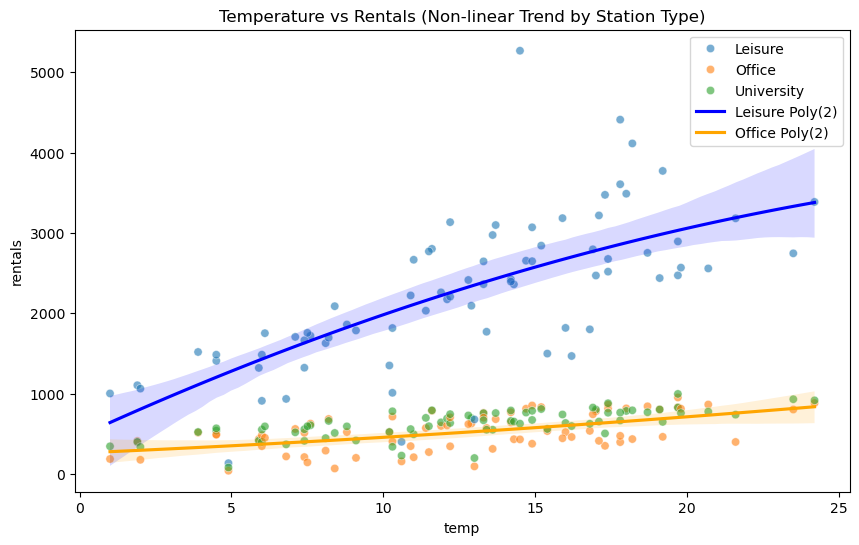

In [9]:
print("\n--- [Ch 7] 기온 변수에 대한 비선형 모델링 (Spline & Poly) ---")

# 1. 다항회귀 (기온 2차항)
design_poly = MS([poly('temp', degree=2), 'station_type', 'is_weekend'])
X_poly = design_poly.fit_transform(daily_df)
model_poly = sm.OLS(y, X_poly).fit()

# 2. 자유도(df) 4의 큐빅 스플라인
design_spline = MS([bs('temp', df=4), 'station_type', 'is_weekend'])
X_spline = design_spline.fit_transform(daily_df)
model_spline = sm.OLS(y, X_spline).fit()

print("\n[스플라인 회귀분석 결과 요약]")
display(summarize(model_spline))

# 3. 비선형 효과 시각화 (산점도와 곡선)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='temp', y='rentals', hue='station_type', data=daily_df, alpha=0.6)
sns.regplot(x='temp', y='rentals', data=daily_df[daily_df['station_type']=='Leisure'], 
            order=2, scatter=False, color='blue', label='Leisure Poly(2)')
sns.regplot(x='temp', y='rentals', data=daily_df[daily_df['station_type']=='Office'], 
            order=2, scatter=False, color='orange', label='Office Poly(2)')

plt.title("Temperature vs Rentals (Non-linear Trend by Station Type)")
plt.legend()
plt.show()